# Project 1: Daily Transit Ridership Analysis

**Data Source:** Data.gov  
**Dataset:** Daily Transit Ridership  
**Source Link:** https://catalog.data.gov/dataset/daily-transit-ridership

**github repo link:** https://github.com/BlazeTheOmega/Project-1.git

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("export.csv")

In [ ]:
df.head()

,Agency,Mode,Date,Week Number,Current Ridership,Year
0,WMATA Bus and Rail,Transit,06/05/2022,24,"266,000","2,022"
1,WMATA Bus and Rail,Transit,06/06/2022,24,"506,000","2,022"
2,WMATA Bus and Rail,Transit,06/07/2022,24,"536,000","2,022"
3,WMATA Bus and Rail,Transit,06/08/2022,24,"551,000","2,022"
4,WMATA Bus and Rail,Transit,06/09/2022,24,"539,000","2,022"


In [ ]:
df.shape

(211, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Agency             211 non-null    object
 1   Mode               211 non-null    object
 2   Date               211 non-null    object
 3   Week Number        211 non-null    int64 
 4   Current Ridership  211 non-null    object
 5   Year               211 non-null    object
dtypes: int64(1), object(5)
memory usage: 10.0+ KB


## 1. Problem Statement

### Dataset Description

The dataset utilized in this analysis is called the Daily Transit Ridership dataset from Data.gov. This dataset consists of ridership data over time and consists of fields such as the transit agency, transportation type, date, week of the year, current ridership, and the year.

The dataset consists of 211 rows and 6 columns.

The main objective of this analysis is to explore the temporal dynamics of the transit ridership and find patterns in the passenger flow.

**Source:** Data.gov  
**Dataset:** Daily Transit Ridership  
**Link:** https://catalog.data.gov/dataset/daily-transit-ridership

### Main Inquiry Question

How has daily transit ridership changed over time?

### Sub-Questions

1. How does average transit ridership vary by week of the year?

2. How does transit ridership compare between different years?

3. What are the highest and lowest ridership periods in the dataset?

## 2. Data Cleaning

Before analyzing the transit ridership data, the dataset will be cleaned by checking for unnecessary columns, missing values, duplicate records, incorrect data types, inconsistent categorical values, and outliers.

In [ ]:
df.columns

Index(['Agency', 'Mode', 'Date', 'Week Number', 'Current Ridership', 'Year'], dtype='object')

### Unwanted Features

The dataset contains six columns. No columns were removed because the available features may be useful for analyzing ridership patterns over time.

In [ ]:
df.isnull().sum()

,0
Agency,0
Mode,0
Date,0
Week Number,0
Current Ridership,0
Year,0


In [ ]:
df[df.isnull().any(axis=1)]

,Agency,Mode,Date,Week Number,Current Ridership,Year


In [ ]:
df.isnull().sum()

,0
Agency,0
Mode,0
Date,0
Week Number,0
Current Ridership,0
Year,0


### Missing Values

The dataset was checked for missing values. There were no missing values found in any of the columns, so no rows or values needed to be removed or replaced.

In [ ]:
df.duplicated().sum()

np.int64(0)

### Duplicate Values

The dataset was checked for duplicate records. There were no duplicate rows found, so no records needed to be removed.

In [ ]:
df.dtypes

,0
Agency,object
Mode,object
Date,object
Week Number,int64
Current Ridership,object
Year,object


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Current Ridership"] = pd.to_numeric(
    df["Current Ridership"].astype(str).str.replace(",", ""),
    errors="coerce"
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

In [ ]:
df.dtypes

,0
Agency,object
Mode,object
Date,datetime64[ns]
Week Number,int64
Current Ridership,int64
Year,float64


### Data Types

Data types were evaluated to ensure that each variable was stored in the correct data type. For instance, Date column was converted to datetime data type and the Current Ridership and Year variables to numeric data types.
This will facilitate further analysis of the data.

In [ ]:
print("Agency values:")
print(df["Agency"].unique())

print("\nMode values:")
print(df["Mode"].unique())

Agency values:
['WMATA Bus and Rail' 'New York City MTA Rail' 'San Francisco BART Rail']

Mode values:
['Transit']


### Categorical Variables

The categorical variables Agency and Mode were checked for inconsistent values. The Agency column contains three consistent agency names, and the Mode column contains one value, Transit. No inconsistent categorical values were found, so no changes were necessary.

In [ ]:
df.describe()

,Date,Week Number,Current Ridership,Year
count,211,211.000000,2.110000e+02,0.0
mean,2022-07-22 21:36:40.947867392,30.454976,1.010681e+06,NaN
min,2022-06-05 00:00:00,24.000000,5.816900e+04,NaN
25%,2022-07-06 00:00:00,28.000000,1.451505e+05,NaN
50%,2022-07-23 00:00:00,31.000000,4.930000e+05,NaN
75%,2022-08-10 00:00:00,33.000000,2.006104e+06,NaN
max,2022-09-03 00:00:00,36.000000,3.256053e+06,NaN
std,NaN,3.121601,1.141201e+06,NaN


In [ ]:
df["Year"] = df["Date"].dt.year

In [ ]:
df["Year"].value_counts()

,count
Year,
2022,211


In [ ]:
Q1 = df["Current Ridership"].quantile(0.25)
Q3 = df["Current Ridership"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Current Ridership"] < lower_bound) |
    (df["Current Ridership"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

outliers

Lower Bound: -2646279.75
Upper Bound: 4797534.25
Number of Outliers: 0


,Agency,Mode,Date,Week Number,Current Ridership,Year


### Outliers

The Current Ridership column was checked for outliers using the IQR method. The lower bound was -2,646,279.75 and the upper bound was 4,797,534.25. No values were identified as outliers, so no records needed to be removed or replaced.

## 3. Exploratory Data Analysis and Interpretation

### Question A: How does average transit ridership vary by week of the year?

To explore this research question, the Average Current Ridership will be computed for each Week Number. This will reveal the changes in average ridership during the time covered by the data set.

In [ ]:
weekly_ridership = df.groupby("Week Number")["Current Ridership"].mean().reset_index()

weekly_ridership

,Week Number,Current Ridership
0,24,4.748571e+05
1,25,4.898571e+05
2,26,4.412857e+05
3,27,1.129552e+06
4,28,9.863386e+05
5,29,1.112541e+06
6,30,1.090077e+06
7,31,1.091580e+06
8,32,1.075486e+06
9,33,1.067298e+06


In [ ]:
import matplotlib.pyplot as plt

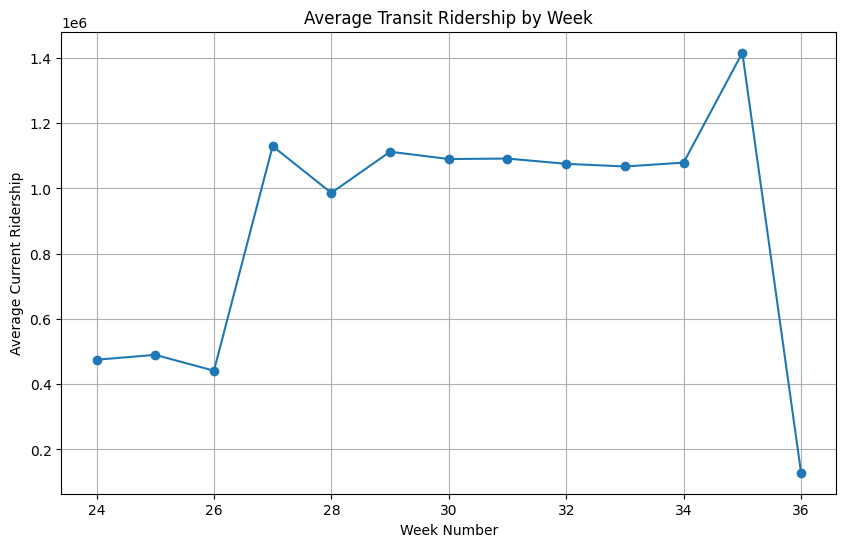

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    weekly_ridership["Week Number"],
    weekly_ridership["Current Ridership"],
    marker="o"
)

plt.title("Average Transit Ridership by Week")
plt.xlabel("Week Number")
plt.ylabel("Average Current Ridership")
plt.grid(True)

plt.show()

In [ ]:
highest_week = weekly_ridership.loc[
    weekly_ridership["Current Ridership"].idxmax()
]

lowest_week = weekly_ridership.loc[
    weekly_ridership["Current Ridership"].idxmin()
]

print("Highest Average Ridership:")
print(highest_week)

print("\nLowest Average Ridership:")
print(lowest_week)

Highest Average Ridership:
Week Number          3.500000e+01
Current Ridership    1.416008e+06
Name: 11, dtype: float64

Lowest Average Ridership:
Week Number              36.000000
Current Ridership    128544.714286
Name: 12, dtype: float64


### Interpretation

From the data, it is clear that there have been major fluctuations in the number of average transit ridership over the weeks analyzed. During Weeks 24 to 26, there were relatively low numbers of transit ridership. Then the number rose drastically in Week 27, remaining relatively constant from Weeks 27 to 34 at roughly one million transit ridership.

Week 35 showed the highest number of average transit ridership with about 1,416,008 ridership. While the lowest number of average transit ridership was seen in Week 36 with roughly 128,545 ridership.

There has been some variation in the number of observations in every week. Weeks 27 to 34 had 21 observations each, Week 35 had 15, and Week 36 had seven observations.

### Question B: How does transit ridership compare among the three transit agencies?

To investigate this question, the average Current Ridership will be calculated for each transit agency. This will allow the ridership levels of the three agencies in the dataset to be compared.

In [ ]:
agency_ridership = df.groupby("Agency")["Current Ridership"].mean().reset_index()

agency_ridership

,Agency,Current Ridership
0,New York City MTA Rail,2.654728e+06
1,San Francisco BART Rail,1.204573e+05
2,WMATA Bus and Rail,4.534935e+05


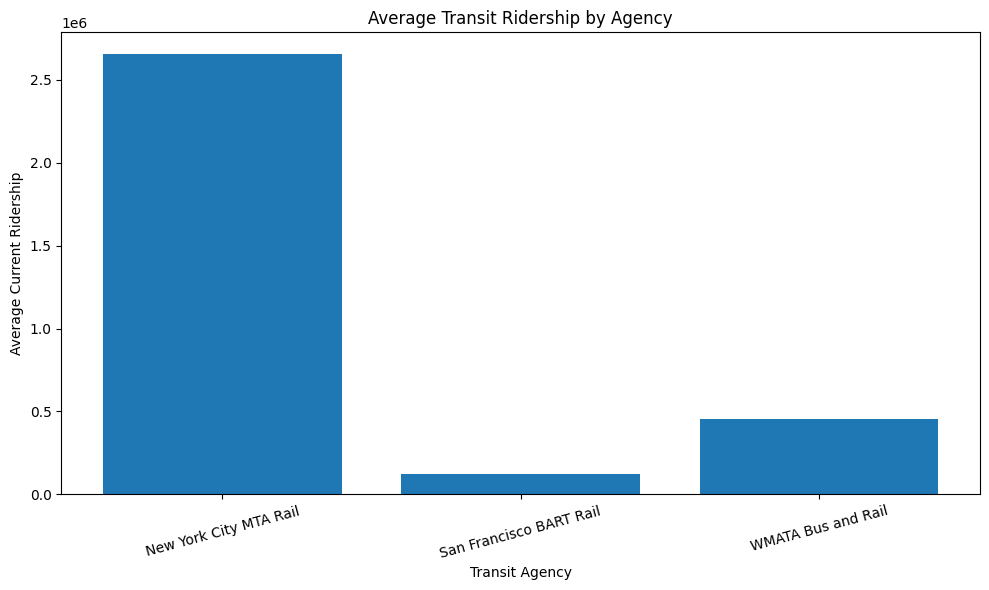

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    agency_ridership["Agency"],
    agency_ridership["Current Ridership"]
)

plt.title("Average Transit Ridership by Agency")
plt.xlabel("Transit Agency")
plt.ylabel("Average Current Ridership")

plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

### Interpretation

There is a significant disparity between the average number of passengers in the three public transport companies. The company with the highest average passenger number is New York City MTA Rail with approximately 2.65 million passengers. WMATA Bus and Rail comes in second with an average of 453,494 passengers, while the company with the lowest average passenger number is San Francisco BART Rail with approximately 120,457 passengers.

From these results, it is evident that New York City MTA Rail had significantly more passengers compared to the other two companies.

### Question C: What are the highest and lowest ridership periods in the dataset?

To investigate this question, the daily ridership values will be examined over time to identify the dates with the highest and lowest Current Ridership values.

In [ ]:
highest_ridership = df.loc[df["Current Ridership"].idxmax()]
lowest_ridership = df.loc[df["Current Ridership"].idxmin()]

print("Highest Ridership:")
print(highest_ridership)

print("\nLowest Ridership:")
print(lowest_ridership)

Highest Ridership:
Agency               New York City MTA Rail
Mode                                Transit
Date                    2022-06-29 00:00:00
Week Number                              27
Current Ridership                   3256053
Year                                   2022
Name: 11, dtype: object

Lowest Ridership:
Agency               San Francisco BART Rail
Mode                                 Transit
Date                     2022-07-31 00:00:00
Week Number                               32
Current Ridership                      58169
Year                                    2022
Name: 176, dtype: object


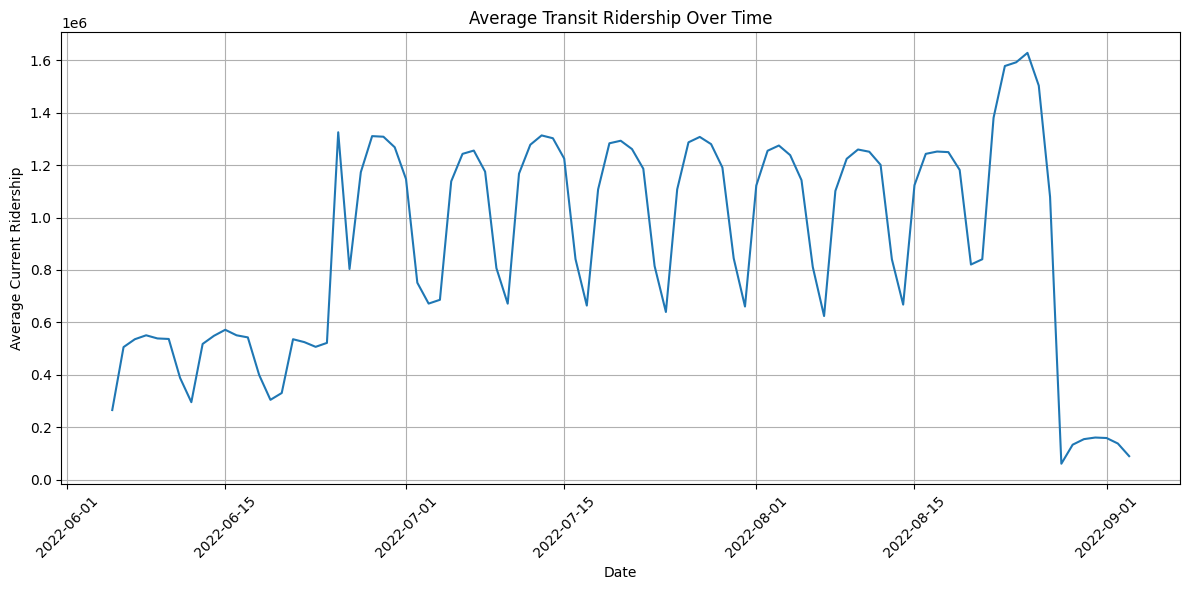

In [ ]:
daily_ridership = df.groupby("Date")["Current Ridership"].mean().reset_index()

plt.figure(figsize=(12, 6))

plt.plot(
    daily_ridership["Date"],
    daily_ridership["Current Ridership"]
)

plt.title("Average Transit Ridership Over Time")
plt.xlabel("Date")
plt.ylabel("Average Current Ridership")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

### Interpretation

There were considerable differences between the highest and lowest individual ridership numbers in the data. The highest ridership number was observed on June 29, 2022, at New York City MTA Rail with 3,256,053 riders. The lowest ridership number was noted on July 31, 2022, at San Francisco BART Rail with 58,169 riders.

As seen from the graph, the average number of riders has been changing over the observation period. There are several times when there is an increase in ridership followed by a decrease. Since there are three different transit agencies in the dataset with very different ridership numbers, some variation can be attributed to the agencies themselves.

In general, the results show that there is a variation in ridership both by date and by transit agency.

## 4. Summary

The data of Daily Transit Ridership were used for analyzing the changes in transit ridership over time. There were 211 observations collected in 2022 for the three agencies: New York City MTA Rail, San Francisco BART Rail, and WMATA Bus and Rail.

It is evident that the average number of riders depends on the week in question. The average number of riders was quite low for Weeks 24-26, it sharply increased during Week 27, and stayed steady further. Week 35 demonstrated the largest number of riders – about 1,416,008 passengers per week, whereas Week 36 had the lowest number of riders – about 128,545 passengers per week.

In addition, there were also significant differences between the three agencies in terms of the average number of riders per week. The largest one was observed for New York City MTA Rail (about 2.65 million), and the lowest one – for San Francisco BART Rail (about 120,457).

In the data set, the highest ridership value is 3,256,053 for New York City MTA Rail on June 29, 2022. The lowest is 58,169 for San Francisco BART Rail on July 31, 2022.

One of the limitations of this study is that the data set used is from 2022 only, meaning changes in various years cannot be studied. In addition, the data set did not mention any reason why the ridership rose or fell in particular days. This means that to find out if any factor influenced the rise or fall of ridership, more information is needed.

Other ways to carry out this analysis can involve using data sets for more years. In addition, an analysis of each transit can be done separately.